In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------------
# Δημιουργία Dataset με 20 Παρατηρήσεις και Ελλείψεις
# ---------------------------------------------------------------

data = {
    'Age': [25, 30, 28, 40, 50, np.nan, 33, 55, 45, 38, 29, 32, 48, 42, 36, 60, 24, 31, 100, np.nan], # 2 NaN + 1 Outlier (100)
    'Income': [30000, 40000, 35000, 50000, 90000, 60000, 45000, 70000, 80000, 42000, 55000, 65000, 75000, np.nan, 58000, 95000, 32000, np.nan, 85000, np.nan], # 3 NaN
    'Gender': ['M', 'F', 'F', 'M', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', np.nan], # 1 NaN
    'Education': ['BSc', 'MSc', 'PhD', 'BSc', 'PhD', 'MSc', 'BSc', 'PhD', 'MSc', 'BSc', 'MSc', 'PhD', 'BSc', 'PhD', 'MSc', 'BSc', 'PhD', 'MSc', 'BSc', 'MSc']
}
df = pd.DataFrame(data)

print("🔹 Αρχικά δεδομένα (20 γραμμές):\n", df)
print("\nΕλλείψεις ανά στήλη:\n", df.isnull().sum())

🔹 Αρχικά δεδομένα (20 γραμμές):
       Age   Income Gender Education
0    25.0  30000.0      M       BSc
1    30.0  40000.0      F       MSc
2    28.0  35000.0      F       PhD
3    40.0  50000.0      M       BSc
4    50.0  90000.0      M       PhD
5     NaN  60000.0      F       MSc
6    33.0  45000.0      F       BSc
7    55.0  70000.0      M       PhD
8    45.0  80000.0      F       MSc
9    38.0  42000.0      M       BSc
10   29.0  55000.0      F       MSc
11   32.0  65000.0      M       PhD
12   48.0  75000.0      F       BSc
13   42.0      NaN      M       PhD
14   36.0  58000.0      F       MSc
15   60.0  95000.0      M       BSc
16   24.0  32000.0      F       PhD
17   31.0      NaN      M       MSc
18  100.0  85000.0      F       BSc
19    NaN      NaN    NaN       MSc

Ελλείψεις ανά στήλη:
 Age          2
Income       3
Gender       1
Education    0
dtype: int64


In [ ]:
# 1. Αφαίρεση της 1 γραμμής με NaN στο Gender (Dropping Row)
# Υποθέτουμε ότι επιλέγουμε την αφαίρεση, καθώς η απώλεια 5% είναι μικρή.
df_cleaned = df.dropna(subset=['Gender'])

print(f"Αρχικές γραμμές: {len(df)}. Γραμμές μετά την αφαίρεση: {len(df_cleaned)}")

Αρχικές γραμμές: 20. Γραμμές μετά την αφαίρεση: 19


In [ ]:
# 1. Αφαίρεση της 1 γραμμής με NaN στο Gender (Dropping Row)
# Υποθέτουμε ότι επιλέγουμε την αφαίρεση, καθώς η απώλεια 5% είναι μικρή.
df_cleaned = df.dropna(subset=['Gender']).copy() # Add .copy() here to avoid the warning

# 2. Imputation Age (Median) στο καθαρό dataset
imputer_median = SimpleImputer(strategy='median')
df_cleaned['Age'] = imputer_median.fit_transform(df_cleaned[['Age']])

# 3. Imputation Income (Mean) στο καθαρό dataset
imputer_mean = SimpleImputer(strategy='mean')
df_cleaned['Income'] = imputer_mean.fit_transform(df_cleaned[['Income']])

print("\nΤελικό dataset μετά το Dropping και την Imputation.")
print(df_cleaned)


Τελικό dataset μετά το Dropping και την Imputation.
      Age        Income Gender Education
0    25.0  30000.000000      M       BSc
1    30.0  40000.000000      F       MSc
2    28.0  35000.000000      F       PhD
3    40.0  50000.000000      M       BSc
4    50.0  90000.000000      M       PhD
5    37.0  60000.000000      F       MSc
6    33.0  45000.000000      F       BSc
7    55.0  70000.000000      M       PhD
8    45.0  80000.000000      F       MSc
9    38.0  42000.000000      M       BSc
10   29.0  55000.000000      F       MSc
11   32.0  65000.000000      M       PhD
12   48.0  75000.000000      F       BSc
13   42.0  59235.294118      M       PhD
14   36.0  58000.000000      F       MSc
15   60.0  95000.000000      M       BSc
16   24.0  32000.000000      F       PhD
17   31.0  59235.294118      M       MSc
18  100.0  85000.000000      F       BSc


In [ ]:
# 1️⃣ Χειρισμός Ονομαστικής Μεταβλητής ('Gender') με One-Hot Encoding
# - Gender: Δεν έχει ιεραρχία.

# Εφαρμογή One-Hot Encoding στη στήλη 'Gender' χωρίς drop_first
df_encoded = pd.get_dummies(df_cleaned, columns=['Gender'], prefix='Gender')

print("--- DataFrame μετά από One-Hot Encoding (χωρίς drop_first) ---")
print(df_encoded.head())

--- DataFrame μετά από One-Hot Encoding (χωρίς drop_first) ---
    Age   Income Education  Gender_F  Gender_M
0  25.0  30000.0       BSc     False      True
1  30.0  40000.0       MSc      True     False
2  28.0  35000.0       PhD      True     False
3  40.0  50000.0       BSc     False      True
4  50.0  90000.0       PhD     False      True


In [ ]:
# 1️⃣ Χειρισμός Ονομαστικής Μεταβλητής ('Gender') με One-Hot Encoding (με drop_first)
# drop_first=True: Αφαιρούμε 1 στήλη για αποφυγή Πολυσυγγραμμικότητας.

# Εφαρμογή One-Hot Encoding στη στήλη 'Gender' με drop_first=True
df_encoded = pd.get_dummies(df_cleaned, columns=['Gender'], prefix='Gender', drop_first= True)

print("\n--- DataFrame μετά από One-Hot Encoding (με drop_first) ---")
print(df_encoded.head())


--- DataFrame μετά από One-Hot Encoding (με drop_first) ---
    Age   Income Education  Gender_M
0  25.0  30000.0       BSc      True
1  30.0  40000.0       MSc     False
2  28.0  35000.0       PhD     False
3  40.0  50000.0       BSc      True
4  50.0  90000.0       PhD      True


In [ ]:
# 2️⃣ Χειρισμός Διατεταγμένης Μεταβλητής ('Education') με Ordinal Encoding
# - Education: Έχει ιεραρχία (BSc < MSc < PhD).

# Ορισμός της σωστής ιεραρχικής σειράς για την Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

education_order = ['BSc', 'MSc', 'PhD']
encoder = OrdinalEncoder(categories=[education_order])

# Apply encoding to the 'Education' column and store it in a new column
df_encoded['Education_Encoded'] = encoder.fit_transform(df_encoded[['Education']])
print("\nDataFrame μετά την προσθήκη της κωδικοποιημένης στήλης Education:")
print(df_encoded.head())


# Αφαίρεση της αρχικής στήλης 'Education'
df_encoded = df_encoded.drop(columns=['Education'])

print("\n--- Τελικό DataFrame μετά την Κωδικοποίηση ---")
# Εμφάνιση των πρώτων γραμμών του τελικού DataFrame με τις κωδικοποιημένες στήλες
print(df_encoded[['Age', 'Income', 'Gender_M', 'Education_Encoded']].head())


DataFrame μετά την προσθήκη της κωδικοποιημένης στήλης Education:
    Age   Income Education  Gender_M  Education_Encoded
0  25.0  30000.0       BSc      True                0.0
1  30.0  40000.0       MSc     False                1.0
2  28.0  35000.0       PhD     False                2.0
3  40.0  50000.0       BSc      True                0.0
4  50.0  90000.0       PhD      True                2.0

--- Τελικό DataFrame μετά την Κωδικοποίηση ---
    Age   Income  Gender_M  Education_Encoded
0  25.0  30000.0      True                0.0
1  30.0  40000.0     False                1.0
2  28.0  35000.0     False                2.0
3  40.0  50000.0      True                0.0
4  50.0  90000.0      True                2.0


In [ ]:
# Κανονικοποίηση z-score
from sklearn.preprocessing import StandardScaler

# Select the columns to scale
columns_to_scale_zscore = ['Age', 'Income']
df_to_scale_zscore = df_encoded[columns_to_scale_zscore]

# Instantiate the StandardScaler
scaler_zscore = StandardScaler()

# Fit and transform the selected columns
scaled_data_zscore = scaler_zscore.fit_transform(df_to_scale_zscore)

# Create a new DataFrame with scaled data and original index
df_zscore_scaled = pd.DataFrame(scaled_data_zscore, columns=columns_to_scale_zscore, index=df_encoded.index)

# Display the first few rows of the Z-score scaled DataFrame
print("DataFrame after Z-score scaling:")
display(df_zscore_scaled.head())

DataFrame after Z-score scaling:


,Age,Income
0,-0.956337,-1.536678
1,-0.661363,-1.011054
2,-0.779353,-1.273866
3,-0.071415,-0.485429
4,0.518534,1.617068


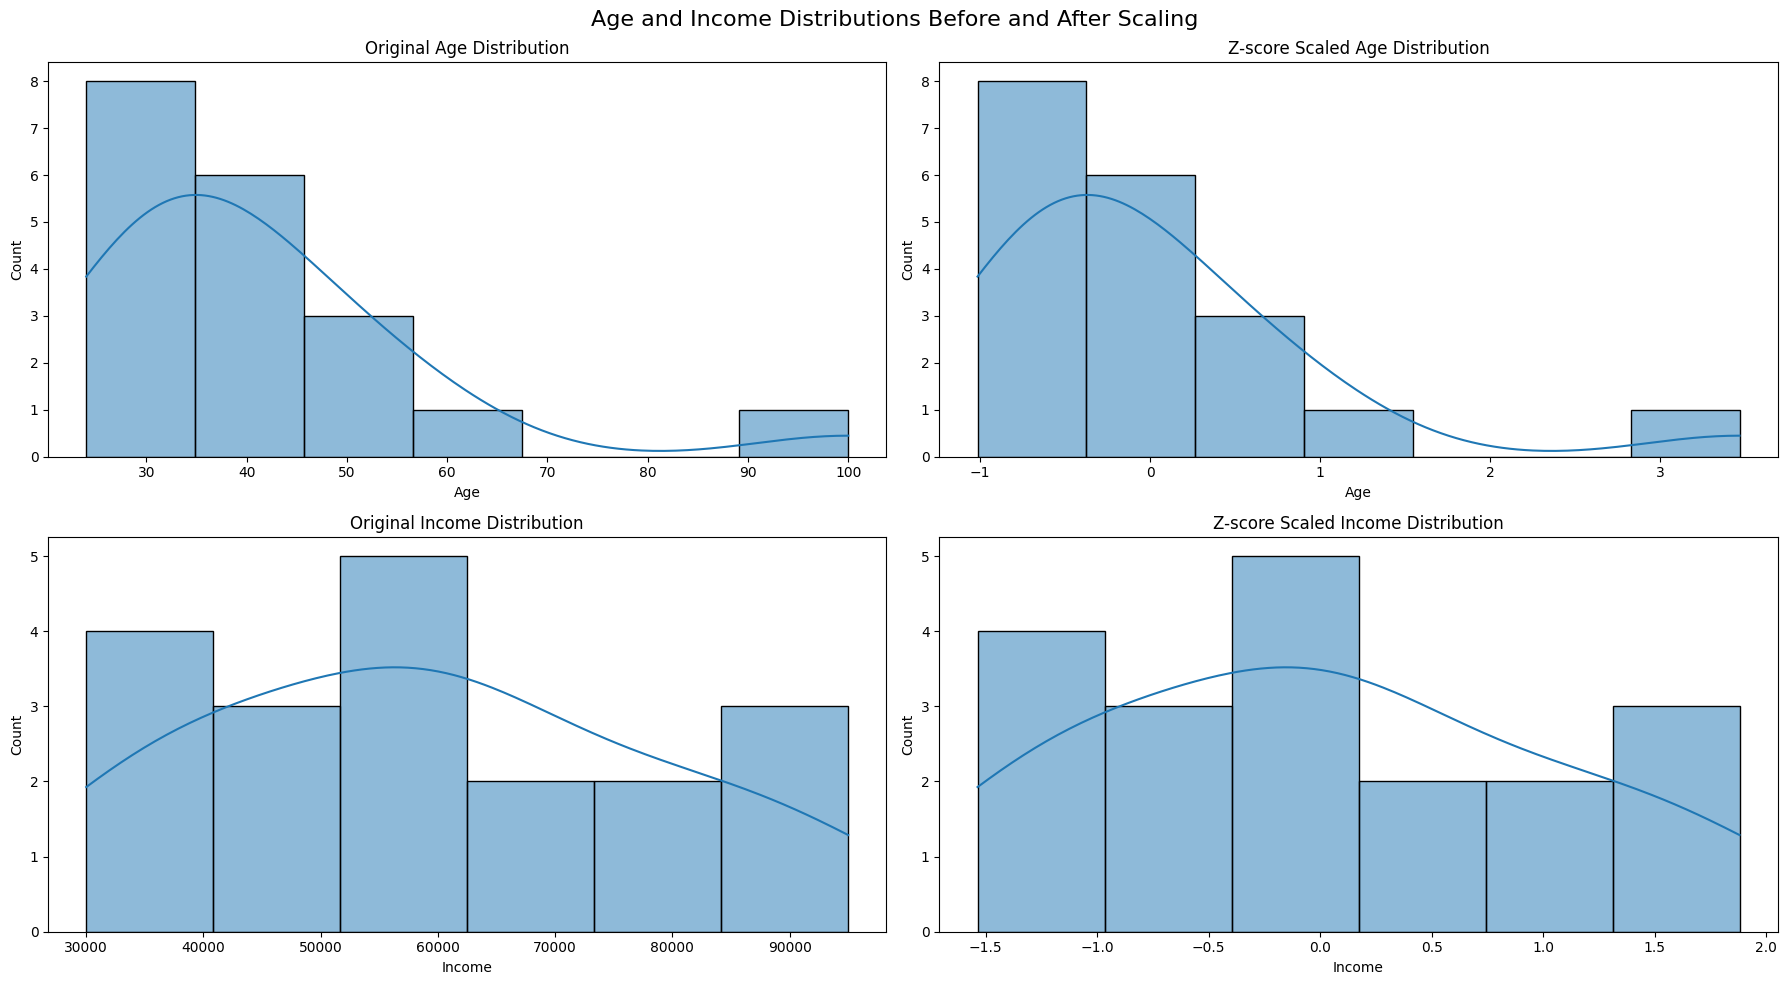

In [ ]:

# Οπτικοποίηση κατανομών πριν και μετά την κανονικοποίηση
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
fig.suptitle("Age and Income Distributions Before and After Scaling", fontsize=16)

# Top row: Age distributions
sns.histplot(df_encoded["Age"], ax=axes[0, 0], kde=True)
axes[0, 0].set_title("Original Age Distribution")

sns.histplot(df_zscore_scaled["Age"], ax=axes[0, 1], kde=True)
axes[0, 1].set_title("Z-score Scaled Age Distribution")


# Bottom row: Income distributions
sns.histplot(df_encoded["Income"], ax=axes[1, 0], kde=True)
axes[1, 0].set_title("Original Income Distribution")

sns.histplot(df_zscore_scaled["Income"], ax=axes[1, 1], kde=True)
axes[1, 1].set_title("Z-score Scaled Income Distribution")


plt.tight_layout()
plt.show()
